<div align='center'>

# **Práctica 2 - Minería de Textos y Análisis de Temas**

**Máster Universitario en Inteligencia Artificial**  
**Asignatura:** Minería de Textos y Modelos de Lenguaje

<br/>
Autores:
- Cristian Rubio Barato - <a href='mailto:Cristian.Rubio@alu.uclm.es'>Cristian.Rubio@alu.uclm.es</a>  
- José Lara Navarro - <a href='mailto:Jose.Lara3@alu.uclm.es'>Jose.Lara3@alu.uclm.es</a>

</div>

<a id='indice'></a>

**Índice**

- [1. Carga, preprocesado y limpieza del conjunto de datos](#sec1)
- [2. Vectorización del corpus](#sec2)
- [3. Modelado y selección del número óptimo de temas](#sec3)
- [4. Declaración de uso responsable de Inteligencia Artificial](#sec4)

<a id='sec1'></a>
## 1. Carga, preprocesado y limpieza del conjunto de datos

Cargamos el dataset, extraemos la columna `cuerpo` como corpus textual y aplicamos el pipeline de preprocesado canónico:

1. **Limpieza básica**: conversión a minúsculas, eliminación de URLs, caracteres no alfabéticos y normalización de espacios en blanco.
2. **Lematización con spaCy** (`es_core_news_sm`): procesamiento por lotes con barra de progreso, filtrando stopwords, puntuación, espacios y tokens de longitud 1. Se desactivan los componentes `parser` y `ner` del pipeline de spaCy, ya que no son necesarios para la lematización y su desactivación reduce notablemente el tiempo de procesamiento. Se usa `n_process=1` porque en Windows (en función del hardware), con modelos grandes, el multiprocesamiento puede provocar errores de memoria; además, la serialización de los objetos `Doc` entre procesos introduce un overhead que, con modelos ligeros como `es_core_news_sm`, anula la ganancia del paralelismo.

El resultado se serializa en `corpus_lemas.pkl` para reutilizarlo en ejecuciones posteriores sin repetir la lematización, que con un corpus de ~58.000 documentos es costosa.

Hay que tener en cuenta que el filtro *is_stop* se evalúa sobre la forma superficial del token, no sobre su lema. Esto significa que, aunque "él" esté en la lista de stopwords de spaCy, un token cuya forma original no se considere stop pero cuyo lema sea "él" puede sobrevivir al filtrado. Con corpus grandes, estos casos se acumulan y el lema resultante puede acabar siendo uno de los términos más frecuentes del vocabulario. Si tras la vectorización detectamos este tipo de situaciones, será necesario valorar filtros adicionales.

In [ ]:
import pandas as pd
import re
import pickle
import os
import spacy
from tqdm import tqdm

df = pd.read_csv("data_larazon_publico_v2.csv")
print(f"Dimensiones del dataset: {df.shape}")

corpus = df["cuerpo"].dropna().reset_index(drop=True)
print(f"Documentos en el corpus (tras eliminar NaN): {len(corpus)}")
print(f"\nEjemplo (primeros 200 caracteres):\n  {corpus.iloc[0][:200]}.")


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", "", texto)
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


corpus_limpio = corpus.apply(limpiar_texto)
print("\nEjemplo original vs. limpio:")
print(f"  Original : {corpus.iloc[0][:100]}")
print(f"  Limpio   : {corpus_limpio.iloc[0][:100]}")

PICKLE_PATH = "corpus_lemas.pkl"


def lematizar_corpus(corpus_serie, batch_size=128):
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
    textos = corpus_serie.tolist()
    salida = []
    for doc in tqdm(
        nlp.pipe(textos, batch_size=batch_size, n_process=1),
        total=len(textos),
        desc="Lematizando",
    ):
        tokens = [
            t.lemma_
            for t in doc
            if not t.is_stop
            and not t.is_punct
            and not t.is_space
            and t.is_alpha
            and len(t.lemma_) > 1
        ]
        salida.append(" ".join(tokens))
    return pd.Series(salida, index=corpus_serie.index)


if os.path.exists(PICKLE_PATH):
    print(f"\nCargando corpus lematizado desde '{PICKLE_PATH}'.")
    with open(PICKLE_PATH, "rb") as f:
        lemas = pickle.load(f)
    print("Corpus cargado correctamente.")
else:
    print("\nIniciando lematización.")
    lemas = lematizar_corpus(corpus_limpio)
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(lemas, f)
    print(f"Corpus guardado en '{PICKLE_PATH}'.")

print("\nEjemplos de texto limpio vs. lematizado:\n")
for i in [0, 1, 2]:
    print(f"  Limpio     : {corpus_limpio.iloc[i][:100]}")
    print(f"  Lematizado : {lemas.iloc[i][:100]}")
    print()

print("Corpus lematizado (Serie de pandas):")
lemas

Dimensiones del dataset: (58424, 4)
Documentos en el corpus (tras eliminar NaN): 58424

Ejemplo (primeros 200 caracteres):
  dos semanas después de su puesta de largo y presentación en sociedad, el primer submarino s-80 para la armada, el s-81 "isaac peral", ha entrado hoy en el agua tras una delicada y larga maniobra que s.

Ejemplo original vs. limpio:
  Original : dos semanas después de su puesta de largo y presentación en sociedad, el primer submarino s-80 para 
  Limpio   : dos semanas después de su puesta de largo y presentación en sociedad el primer submarino s para la a

Iniciando lematización.


Lematizando: 100%|██████████| 58424/58424 [26:57<00:00, 36.12it/s]   


Corpus guardado en 'corpus_lemas.pkl'.

Ejemplos de texto limpio vs. lematizado:

  Limpio     : dos semanas después de su puesta de largo y presentación en sociedad el primer submarino s para la a
  Lematizado : semana puesta presentación sociedad submarino armada isaac peral entrar agua delicado largo maniobra

  Limpio     : este viernes el presidente del gobierno pedro sánchez y las cuatro vicepresidentas carmen calvo nadi
  Lematizado : viernes presidente gobierno pedro sánchez vicepresidenta carmen calvo nadia calviño yolanda díaz ter

  Limpio     : el ministro del interior fernando grande marlaska y el alcalde de guadalajara alberto rojo blas han 
  Lematizado : ministro interior fernando marlaska alcalde guadalajara alberto rojo bla suscribir convenio colabora

Corpus lematizado (Serie de pandas):


0        semana puesta presentación sociedad submarino ...
1        viernes presidente gobierno pedro sánchez vice...
2        ministro interior fernando marlaska alcalde gu...
3        duro familia olivia anna gimeno zimmerman cump...
4        quedar preso eta recibir beneficio traslado pa...
                               ...                        
58419    comisión europea iniciar procedimiento infracc...
58420    pleno asamblea madrid aprobar jueves proyecto ...
58421    comisión investigación parlamentario accidente...
58422    erc pdecat calificar jueves inaceptable grabac...
58423    junta portavoz congreso acordar oposición pp a...
Length: 58424, dtype: str

<a id='sec2'></a>
## 2. Vectorización del corpus

Transformamos el corpus lematizado en una representación numérica mediante **Bag of Words (BoW)** con `CountVectorizer` de scikit-learn, tal y como se ha trabajado en las sesiones de clase.

Con ~58.000 documentos, los umbrales de frecuencia mínima (`min_df`) admiten valores absolutos mucho mayores que en la P1 sin perder cobertura: un `min_df=20`, por ejemplo, solo exige que un término aparezca en el 0.03% del corpus. Probamos varias combinaciones de n-gramas, `min_df`, `max_df` y `max_features` para observar cómo varía el tamaño del vocabulario antes de fijar la configuración definitiva.

In [2]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

configuraciones = [
    {"ngram_range": (1, 1), "min_df": 5,     "max_df": 0.95, "max_features": None},
    {"ngram_range": (1, 1), "min_df": 10,    "max_df": 0.90, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 10,    "max_df": 0.90, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 20,    "max_df": 0.90, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 20,    "max_df": 0.90, "max_features": 10000},
    {"ngram_range": (1, 2), "min_df": 50,    "max_df": 0.85, "max_features": 10000},
    {"ngram_range": (1, 2), "min_df": 100,   "max_df": 0.85, "max_features": 10000},
    {"ngram_range": (1, 2), "min_df": 0.005, "max_df": 0.80, "max_features": 10000},
]

print(
    f"{'Config':<8} {'n-gramas':<12} {'min_df':<10} {'max_df':<8} {'max_feat':<12} {'Terminos':<10}"
)
print("-" * 64)
for i, config in enumerate(configuraciones):
    vec_tmp = CountVectorizer(**config)
    dtm_tmp = vec_tmp.fit_transform(lemas)
    mf = config["max_features"]
    print(
        f"  {i + 1:<6} {str(config['ngram_range']):<12} {str(config['min_df']):<10} "
        f"{config['max_df']:<8} {str(mf):<12} {dtm_tmp.shape[1]:<10}"
    )

# --- Configuración elegida ---
# Config 5: bigramas (1,2), min_df=20, max_df=0.90, max_features=10000.
#
# Razonamiento:
# - Incluir bigramas (configs 3-8) captura expresiones relevantes como "toque queda"
#   o "millón euros" que un modelo de unigramas perdería.
# - Sin max_features, los bigramas disparan el vocabulario (config 3: ~200K, config 4: ~88K),
#   lo que ralentiza el entrenamiento y diluye los temas con n-gramas de baja frecuencia.
# - max_features=10000 es una cota razonable para NMF/LDA sobre este corpus.
# - Entre las configs con max_features=10000, elegimos min_df=20 (config 5) porque es el
#   umbral más permisivo que ya queda acotado por max_features: con min_df más altos (50, 100)
#   se pierden términos potencialmente informativos sin ganancia real, ya que el vocabulario
#   ya estaba limitado a 10000.

print("\n" + "=" * 60)
print("=== VECTORIZACION FINAL: BAG OF WORDS ===")
print("=" * 60)

vectorizador = CountVectorizer(
    ngram_range=(1, 2), min_df=20, max_df=0.90, max_features=10000
)
dtm_sparse = vectorizador.fit_transform(lemas)
feature_names = vectorizador.get_feature_names_out()

dtm_df = pd.DataFrame.sparse.from_spmatrix(dtm_sparse, columns=feature_names)
print("\n1) Matriz DTM (Document-Term Matrix):")
print(dtm_df)

print(f"\n2) Tamaño final del DTM:")
print(f"   Documentos : {dtm_sparse.shape[0]}")
print(f"   Terminos   : {dtm_sparse.shape[1]}")

sumas = np.asarray(dtm_sparse.sum(axis=0)).flatten()
top20_idx = sumas.argsort()[::-1][:20]
top20 = pd.Series(sumas[top20_idx], index=feature_names[top20_idx])
print("\n3) Top 20 terminos mas frecuentes (BoW):")
print(top20.to_string())

Config   n-gramas     min_df     max_df   max_feat     Terminos  
----------------------------------------------------------------
  1      (1, 1)       5          0.95     None         41522     
  2      (1, 1)       10         0.9      None         28276     
  3      (1, 2)       10         0.9      None         199671    
  4      (1, 2)       20         0.9      None         88064     
  5      (1, 2)       20         0.9      10000        10000     
  6      (1, 2)       50         0.85     10000        10000     
  7      (1, 2)       100        0.85     10000        10000     
  8      (1, 2)       0.005      0.8      10000        10000     

=== VECTORIZACION FINAL: BAG OF WORDS ===

1) Matriz DTM (Document-Term Matrix):
       abad  abajo  abandonar  abandonar aconsejar  abandonar constatar  \
0         0      0          0                    0                    0   
1         0      0          0                    0                    0   
2         0      0          0     

### Observaciones sobre la vectorización

El top 20 de términos más frecuentes revela un dato llamativo: "él" ocupa la primera posición con 136.839 apariciones, muy por encima del segundo término ("gobierno", con 122.018). Se trata del lema al que spaCy unifica diversas formas pronominales y del artículo determinado ("el", "lo", "le", etc.). Aunque "él" sí está incluido en la lista de stopwords de `es_core_news_sm`, el filtro `is_stop` se evalúa sobre la forma superficial del token, no sobre el lema resultante. Esto provoca que ciertos tokens cuya forma original no está marcada como stop (por ejemplo, usos de "el" que el POS tagger interpreta como parte de un nombre propio o como determinante en contextos ambiguos) sobrevivan al filtrado, y al lematizarse todos converjan en "él", acumulándose masivamente en el vocabulario. No aporta información temática y, como veremos más adelante, aparece entre las palabras representativas de varios temas, restándoles limpieza.

Para mitigarlo se podría filtrar "él" directamente a nivel de vectorización (parámetro stop_words de CountVectorizer o una lista de exclusión ad hoc), o bien aplicar el filtro de stopwords sobre el lema en lugar de sobre la forma original. En nuestro caso lo dejamos sin filtrar para mostrar el efecto que tiene y discutirlo, pero en un pipeline de producción debería eliminarse.

Respecto a la tabla comparativa de configuraciones, se observa que el top 10 de términos es idéntico en las ocho configuraciones. Esto es esperable: los términos más frecuentes del corpus sobreviven a cualquier combinación razonable de `min_df` y `max_df`. Las diferencias entre configuraciones se concentran en la cola del vocabulario, es decir, en los términos de frecuencia media-baja que cada filtro incluye o descarta.

La configuración elegida (config 5: bigramas, `min_df=20`, `max_df=0.90`, `max_features=10000`) se justifica así: incluir bigramas permite capturar expresiones relevantes como "toque queda" o "millón euros" que un modelo solo de unigramas perdería. Sin `max_features`, los bigramas disparan el vocabulario a casi 88.000 términos (config 4), lo que ralentiza el entrenamiento y diluye los temas con n-gramas de baja frecuencia. Acotar a 10.000 features es razonable para NMF/LDA sobre este corpus. Entre las configuraciones que aplican esa cota (configs 5 a 8), elegimos `min_df=20` porque es el umbral más permisivo que ya queda controlado por `max_features`: subir a 50 o 100 (configs 6 y 7) descartaría términos potencialmente informativos sin ganancia real, dado que el vocabulario ya está limitado.

<a id='sec3'></a>
## 3. Modelado y selección del número óptimo de temas

A partir de la DTM construida en la sección anterior, aplicamos modelos de **factorización no negativa de matrices (NMF)** y **LDA** para descubrir los temas latentes del corpus.

- **Celda 1**: entrenamiento NMF con exploración manual del número de temas, extracción de palabras representativas y asignación de títulos.
- **Celda 2**: barrido de K (2-10) con similitud coseno media entre temas para evaluar redundancia.
- **Celda 3**: barrido de K con LDA mediante perplejidad y comparación de los tres criterios.

In [ ]:
import numpy as np
import pandas as pd
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import NMF

# Reconstruir DTM si esta celda se ejecuta de forma aislada
try:
    dtm_sparse
    feature_names
    print("DTM ya disponible en memoria.")
except NameError:
    print("Reconstruyendo DTM desde pickle.")
    with open("corpus_lemas.pkl", "rb") as f:
        lemas = pickle.load(f)
    vectorizador = CountVectorizer(
        ngram_range=(1, 2), min_df=20, max_df=0.90, max_features=10000
    )
    dtm_sparse = vectorizador.fit_transform(lemas)
    feature_names = vectorizador.get_feature_names_out()
    print(f"DTM reconstruida: {dtm_sparse.shape[0]} docs x {dtm_sparse.shape[1]} terminos")

N_PALABRAS = 15

def entrenar_nmf_y_mostrar(K, dtm, feat_names, titulos=None):
    """Entrena NMF con K temas y muestra las palabras mas representativas."""
    nmf = NMF(n_components=K, random_state=42, max_iter=400, init="nndsvda")
    W = nmf.fit_transform(dtm)
    H = nmf.components_
    print(f"  W: {W.shape}  |  H: {H.shape}  |  Error Frobenius: {nmf.reconstruction_err_:.2f}")

    for k in range(K):
        top_idx = H[k].argsort()[::-1][:N_PALABRAS]
        top_words = ", ".join(feat_names[top_idx])
        etiqueta = f" | {titulos[k]}" if titulos else ""
        print(f"    Tema {k+1:>2}{etiqueta}:  {top_words}")
    return nmf, W, H


# --- Exploración progresiva, como se hace en clase ---
# Empezamos con valores bajos de K e incrementamos para observar
# cuándo los temas empiezan a ser redundantes o a fragmentarse.

for k_test in [4, 5, 6, 7, 8]:
    print(f"\n{'='*70}")
    print(f"  NMF con K = {k_test}")
    print(f"{'='*70}")
    entrenar_nmf_y_mostrar(k_test, dtm_sparse, feature_names)

# --- Selección final: K elegido tras la exploración ---
K_FINAL = 8  # AJUSTAR TRAS REVISAR LA SALIDA
print(f"\n{'#'*70}")
print(f"  SELECCION FINAL: K = {K_FINAL}")
print(f"{'#'*70}")

# Títulos asignados manualmente a partir de las palabras representativas.
# RELLENAR TRAS REVISAR LA SALIDA DE LA EXPLORACIÓN.
titulos = {
    0: "Restricciones sanitarias COVID",
    1: "Política de partidos y elecciones",
    2: "Podemos: crisis y liderazgo interno",
    3: "Turismo, ocio y estilo de vida",
    4: "Terrorismo y política penitenciaria",
    5: "Ciencia, universidad y pandemia",
    6: "Restricciones COVID por comunidades",
    7: "Economía, empleo y gasto público",
}

nmf_final, W_final, H_final = entrenar_nmf_y_mostrar(
    K_FINAL, dtm_sparse, feature_names, titulos
)

# Distribución de documentos por tema dominante
tema_dominante = W_final.argmax(axis=1)
dist = pd.Series(tema_dominante).value_counts().sort_index()
dist.index = [f"Tema {i+1} - {titulos[i]}" for i in dist.index]
print("\nDocumentos por tema dominante:")
print(dist.to_string())
print(f"\nTotal: {dist.sum()}")

DTM ya disponible en memoria.

  NMF con K = 4
  W: (58424, 4)  |  H: (4, 10000)  |  Error Frobenius: 6045.59
    Tema  1:  hora, persona, mantener, aforo, toque, hostelería, queda, toque queda, máximo, interior, cierre, reunión, máximo persona, nivel, perimetral
    Tema  2:  gobierno, él, año, pp, partido, españa, sánchez, madrid, presidente, psoe, caso, ciudadano, general, político, público
    Tema  3:  iglesia, partido, él, pablo, ver, proyecto, dirección, problema, error, fundador, espinar, cañamero, izquierda, madrid, secretario
    Tema  4:  él, venir, benidorm, semana, playa, gente, año, ver, ciudad, región, vasco, viaje, hotel, país, explicar

  NMF con K = 5
  W: (58424, 5)  |  H: (5, 10000)  |  Error Frobenius: 5932.66
    Tema  1:  hora, persona, mantener, aforo, toque, hostelería, queda, toque queda, máximo, interior, cierre, reunión, máximo persona, nivel, perimetral
    Tema  2:  gobierno, él, pp, año, partido, españa, sánchez, madrid, psoe, presidente, ciudadano, polít

### Análisis de los temas NMF

Siguiendo la metodología vista en clase, exploramos el número de temas de forma progresiva, empezando con K=4 e incrementando hasta K=8, para observar en qué momento los temas dejan de aportar información nueva y empiezan a fragmentarse o repetirse.

**K=4** produce una primera separación en bloques muy amplios: restricciones sanitarias COVID, un bloque político genérico que mezcla partidos y gobierno, un tema centrado en la política interna de Podemos (Iglesias, Espinar, Cañamero), y un tema difuso de turismo/ocio (Benidorm, playa, hotel). Son temas comprensibles pero muy gruesos: la política absorbe prácticamente todo lo que no sea COVID o turismo.

**K=5** escinde un tema de terrorismo y política penitenciaria (ETA, víctima, audiencia nacional) que antes quedaba diluido en el bloque político. Es un tema coherente y bien definido que justifica el salto.

**K=6** separa un bloque de economía, ciencia y pandemia (millón, vacuna, empresa, virus) del bloque político. Aquí los seis temas son razonablemente limpios: cada uno tiene un núcleo léxico diferenciado y no se observan solapamientos evidentes.

**K=7** es donde aparece el primer problema serio de redundancia. El tema de restricciones COVID, que hasta ahora era uno solo, se fragmenta en dos: el Tema 1 (hora, aforo, hostelería, toque queda, interior) y el Tema 7 (hora, comunidad, toque queda, limitación, hostelería, movilidad). Ambos comparten la mayoría del vocabulario y representan matices del mismo fenómeno: restricciones sanitarias desde el punto de vista de las normas concretas (Tema 1) frente a su aplicación por comunidades autónomas (Tema 7). Es una fragmentación que no aporta información temática realmente nueva.

**K=8** mantiene esa redundancia entre los Temas 1 y 7, pero a cambio separa ciencia/pandemia (vacuna, investigación, coronavirus, universidad, CSIC) de economía/empleo (millón, euros, empresa, trabajo, discapacidad). Esta separación es semánticamente valiosa: son dos bloques temáticos con vocabulario claramente distinto.

Nos quedamos con **K=8** porque esa separación de ciencia y economía compensa razonablemente la redundancia en los temas COVID, que en todo caso son coherentes entre sí y no generan confusión interpretativa. No obstante, K=6 sería una alternativa igualmente defendible si se prioriza la limpieza sobre la granularidad.

Los títulos asignados a cada tema responden directamente a las palabras representativas:

| Tema | Título | Justificación |
|------|--------|---------------|
| 1 | Restricciones sanitarias COVID | aforo, hostelería, toque queda, cierre, reunión |
| 2 | Política de partidos y elecciones | gobierno, PP, Sánchez, PSOE, Vox, elección, voto, congreso |
| 3 | Podemos: crisis y liderazgo interno | Iglesias, Pablo, Espinar, Cañamero, Errejón, fundador |
| 4 | Turismo, ocio y estilo de vida | Benidorm, playa, viaje, hotel, vasco, ciudad |
| 5 | Terrorismo y política penitenciaria | penitenciario, ETA, víctima, terrorismo, audiencia nacional |
| 6 | Ciencia, universidad y pandemia | vacuna, investigación, virus, coronavirus, CSIC |
| 7 | Restricciones COVID por comunidades | comunidad, toque queda, limitación, movilidad, horario |
| 8 | Economía, empleo y gasto público | millón, euros, empresa, trabajo, discapacidad |

Respecto a la distribución de documentos por tema dominante, destaca el fuerte desequilibrio: el Tema 8 (economía) absorbe 27.461 documentos (47%) y el Tema 2 (política) otros 21.877 (37%). Juntos representan el 84% del corpus. Esto tiene sentido tratándose de prensa generalista española, donde la cobertura política y económica domina la agenda informativa, pero conviene tenerlo presente: los temas minoritarios (Tema 6 con solo 734 documentos, Tema 7 con 1.051) están representados por muchos menos textos, lo que podría afectar a la estabilidad de sus vectores tema-palabra.

Por último, cabe señalar que el lema "él" aparece entre las palabras representativas de cinco de los ocho temas (2, 3, 4, 5 y 8). Como se discutió en la Sección 2, aunque "él" forma parte de las stopwords de spaCy, el filtro `is_stop` opera sobre la forma superficial del token y no sobre el lema, por lo que muchas formas que convergen en "él" tras la lematización no son interceptadas. El resultado es que "él" actúa como ruido que se reparte por los temas sin aportar capacidad discriminativa. Si lo hubiésemos excluido a nivel de vectorización, las palabras representativas de cada tema serían algo más limpias, aunque la estructura temática general no cambiaría sustancialmente.

Barrido NMF (K = 2...10).
  K= 2  ->  sim_coseno_media = 0.1909
  K= 3  ->  sim_coseno_media = 0.1895
  K= 4  ->  sim_coseno_media = 0.1856
  K= 5  ->  sim_coseno_media = 0.1629
  K= 6  ->  sim_coseno_media = 0.1749
  K= 7  ->  sim_coseno_media = 0.1874
  K= 8  ->  sim_coseno_media = 0.1694
  K= 9  ->  sim_coseno_media = 0.1525
  K=10  ->  sim_coseno_media = 0.1473

----------------------------------------
  K  |  Similitud coseno media
----------------------------------------
   2  |  0.1909
   3  |  0.1895
   4  |  0.1856
   5  |  0.1629
   6  |  0.1749
   7  |  0.1874
   8  |  0.1694  << manual
   9  |  0.1525
  10  |  0.1473  << min sim
----------------------------------------


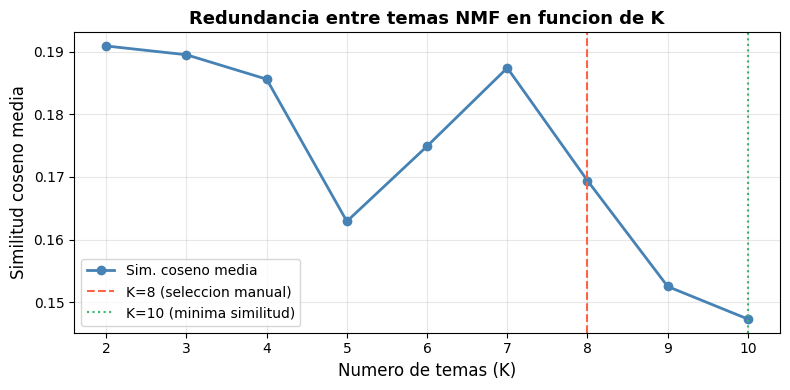

Grafica guardada en 'similitud_coseno_K.png'.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

K_RANGE = range(2, 11)


def similitud_coseno_media(H):
    """Similitud coseno promedio entre todos los pares de vectores tema-palabra."""
    sim_matrix = cosine_similarity(H)
    K = sim_matrix.shape[0]
    upper = sim_matrix[np.triu_indices(K, k=1)]
    return upper.mean()


print("Barrido NMF (K = 2...10).")
resultados = []
for k in K_RANGE:
    nmf_k = NMF(n_components=k, random_state=42, max_iter=400, init="nndsvda")
    nmf_k.fit(dtm_sparse)
    sim = similitud_coseno_media(nmf_k.components_)
    resultados.append({"K": k, "Similitud coseno media": round(sim, 4)})
    print(f"  K={k:>2}  ->  sim_coseno_media = {sim:.4f}")

df_res = pd.DataFrame(resultados).set_index("K")

# Identificar el K con menor similitud (temas mas diferenciados)
k_min_sim = int(df_res["Similitud coseno media"].idxmin())

print("\n" + "-" * 40)
print("  K  |  Similitud coseno media")
print("-" * 40)
for k, row in df_res.iterrows():
    marcas = []
    if k == K_FINAL:
        marcas.append("manual")
    if k == k_min_sim:
        marcas.append("min sim")
    marca = f"  << {', '.join(marcas)}" if marcas else ""
    print(f"  {k:>2}  |  {row['Similitud coseno media']:.4f}{marca}")
print("-" * 40)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_res.index, df_res["Similitud coseno media"],
        marker="o", linewidth=2, color="steelblue", label="Sim. coseno media")
ax.axvline(x=K_FINAL, color="tomato", linestyle="--", linewidth=1.5,
           label=f"K={K_FINAL} (seleccion manual)")
ax.axvline(x=k_min_sim, color="mediumseagreen", linestyle=":", linewidth=1.5,
           label=f"K={k_min_sim} (minima similitud)")
ax.set_xlabel("Numero de temas (K)", fontsize=12)
ax.set_ylabel("Similitud coseno media", fontsize=12)
ax.set_title("Redundancia entre temas NMF en funcion de K", fontsize=13, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("similitud_coseno_K.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada en 'similitud_coseno_K.png'.")

### Interpretación: similitud coseno media

La similitud coseno media cuantifica el solapamiento promedio entre los vectores tema‑palabra (filas de **H**):

- **Valores altos** → los temas son redundantes (léxico muy compartido).
- **Valores bajos** → los temas son más distintos y complementarios.

Al aumentar K, los temas se fragmentan y el vocabulario compartido disminuye, por lo que la similitud desciende de forma aproximadamente monótona. El codo de la curva señala el punto donde añadir más temas aporta poca ganancia en diferenciación.

Los resultados del barrido son:

| K | Sim. coseno media |
|---|---|
| 2 | 0.1909 |
| 3 | 0.1895 |
| 4 | 0.1856 |
| **5** | **0.1629** (mínimo local) |
| 6 | 0.1749 |
| 7 | 0.1874 |
| 8 | 0.1694 |
| 9 | 0.1525 |
| **10** | **0.1473** (mínimo global) |

Lo primero que se observa es que la curva **no es monótonamente decreciente**, a diferencia de lo que podría esperarse en principio. Hay un mínimo local claro en K=5 (0.1629), seguido de un repunte en K=6 y especialmente en K=7 (0.1874, el valor más alto después de K=2-3), para luego volver a descender hasta K=10. Esto coincide con lo que se explica en clase: la similitud media no siempre baja de forma limpia al aumentar K, porque al fragmentar temas coherentes se pueden generar subtemas que comparten vocabulario y elevan la similitud puntualmente.

El repunte en K=7 tiene una explicación directa si miramos la exploración de la celda anterior: es exactamente el punto donde el tema de restricciones COVID se fragmenta en dos temas con vocabulario casi idéntico (Temas 1 y 7). Esa redundancia eleva la similitud coseno media. En K=8, la posterior separación de ciencia y economía compensa parcialmente el efecto, bajando la similitud a 0.1694.

El mínimo global se alcanza en K=10 (0.1473), pero un menor valor de similitud no implica necesariamente temas más interpretables: con K alto, los temas se vuelven tan específicos que pierden coherencia semántica a cambio de diferenciación numérica.

Si atendemos exclusivamente a esta métrica, K=5 y K=9-10 serían los candidatos preferentes. Nuestra elección de K=8 presenta una similitud intermedia (0.1694), lo cual es coherente con el hecho de que asumimos conscientemente una redundancia en los temas COVID a cambio de mayor granularidad en otras áreas.

Barrido LDA (K = 2...10).
  K= 2  ->  perplejidad = 3270.40
  K= 3  ->  perplejidad = 2649.26
  K= 4  ->  perplejidad = 2229.78
  K= 5  ->  perplejidad = 2114.81
  K= 6  ->  perplejidad = 1911.10
  K= 7  ->  perplejidad = 1813.10
  K= 8  ->  perplejidad = 1727.24
  K= 9  ->  perplejidad = 1633.59
  K=10  ->  perplejidad = 1616.75

-----------------------------------
  K  |  Perplejidad LDA
-----------------------------------
   2  |     3270.40
   3  |     2649.26
   4  |     2229.78
   5  |     2114.81
   6  |     1911.10
   7  |     1813.10
   8  |     1727.24
   9  |     1633.59
  10  |     1616.75
-----------------------------------

  Minima perplejidad en el rango explorado: K = 10 (1616.75)


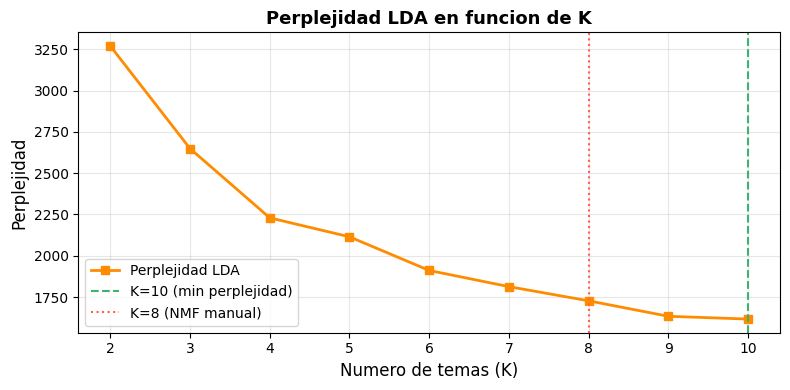

Grafica guardada en 'perplejidad_lda_K.png'.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation

K_RANGE = range(2, 11)

# Se usa learning_method='online' en lugar de 'batch' (usado en clase con corpus
# mas pequeños) porque con ~58.000 documentos el modo online procesa los datos
# en mini-lotes, lo que reduce el consumo de memoria y el tiempo de entrenamiento.
# max_iter=30: suficiente para estabilizar la tendencia de perplejidad entre valores
# de K. Las perplejidades resultantes son comparativas (útiles para ordenar K),
# aunque no necesariamente reflejan la convergencia plena de cada modelo individual.
print("Barrido LDA (K = 2...10).")
perpleji = []
for k in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=30,
        learning_method="online",
        batch_size=2048,
    )
    lda_k.fit(dtm_sparse)
    perp = lda_k.perplexity(dtm_sparse)
    perpleji.append({"K": k, "Perplejidad": round(perp, 2)})
    print(f"  K={k:>2}  ->  perplejidad = {perp:.2f}")

df_lda = pd.DataFrame(perpleji).set_index("K")

print("\n" + "-" * 35)
print("  K  |  Perplejidad LDA")
print("-" * 35)
for k, row in df_lda.iterrows():
    print(f"  {k:>2}  |  {row['Perplejidad']:>10.2f}")
print("-" * 35)
k_opt_lda = int(df_lda["Perplejidad"].idxmin())
print(
    f"\n  Minima perplejidad en el rango explorado: K = {k_opt_lda} ({df_lda.loc[k_opt_lda, 'Perplejidad']:.2f})"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    df_lda.index,
    df_lda["Perplejidad"],
    marker="s",
    linewidth=2,
    color="darkorange",
    label="Perplejidad LDA",
)
ax.axvline(
    x=k_opt_lda,
    color="mediumseagreen",
    linestyle="--",
    linewidth=1.5,
    label=f"K={k_opt_lda} (min perplejidad)",
)
ax.axvline(x=K_FINAL, color="tomato", linestyle=":", linewidth=1.5, label=f"K={K_FINAL} (NMF manual)")
ax.set_xlabel("Numero de temas (K)", fontsize=12)
ax.set_ylabel("Perplejidad", fontsize=12)
ax.set_title("Perplejidad LDA en funcion de K", fontsize=13, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("perplejidad_lda_K.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada en 'perplejidad_lda_K.png'.")

### Comparación de criterios

| Criterio | K sugerido | Observación |
|---|---|---|
| Inspección manual (NMF) | 6-8 | K=6 sin redundancia; K=8 con mayor granularidad pero redundancia en COVID |
| Similitud coseno (NMF) | 5 o 10 | Mínimo local en K=5, mínimo global en K=10 |
| Perplejidad (LDA) | 10 | Descenso monótono, mínimo en el extremo del rango explorado |

Los tres criterios **no convergen** en un único valor de K, y es importante decirlo con claridad en lugar de forzar una narrativa de coincidencia.

La perplejidad de LDA desciende de forma monótona de K=2 (3270) a K=10 (1617). Esto es un comportamiento habitual: modelos con más componentes se ajustan mejor a los datos de entrenamiento, por lo que la perplejidad siempre tenderá a bajar. Como se explica en clase, el mínimo numérico no marca necesariamente el número semánticamente óptimo de temas, sino el punto de mayor ajuste estadístico. Además, hemos utilizado `max_iter=30` y `learning_method='online'` (frente al `'batch'` empleado en las sesiones de clase con corpus más pequeños), lo que significa que las perplejidades son comparativas entre valores de K pero no reflejan la convergencia completa de cada modelo individual. El modo online se justifica aquí por eficiencia: con ~58.000 documentos, el procesamiento por mini-lotes reduce significativamente el consumo de memoria y el tiempo de entrenamiento.

La similitud coseno muestra un comportamiento no monótono con mínimos en K=5 y K=10, y un repunte notable en K=7 que corresponde a la fragmentación redundante del tema COVID.

La inspección manual, que en última instancia es el criterio más relevante cuando se busca interpretabilidad, sugiere que K=6 ofrece la partición más limpia (sin redundancia entre temas), mientras que K=8 añade granularidad útil (separación de ciencia y economía) a costa de duplicar el tema de restricciones COVID.

Optamos por **K=8** como elección final, asumiendo explícitamente ese trade-off. La redundancia entre los Temas 1 y 7 es un coste menor si tenemos en cuenta que ambos son coherentes en sí mismos y que la ganancia en las demás áreas temáticas compensa la duplicidad.

<a id='sec4'></a>
## 4. Declaración de uso responsable de Inteligencia Artificial

En este trabajo se ha utilizado Inteligencia Artificial únicamente como herramienta de apoyo técnico y de mejora de presentación, sin sustituir la autoría académica del contenido.

Usos concretos de la IA durante el desarrollo:
- Asistencia puntual de código para mejorar visualizaciones.
- Apoyo general en tareas técnicas secundarias.
- Mejora de la redacción de algunos apartados.
- Revisión de estilo y formateo en Markdown.

El planteamiento del trabajo, la estructura, las decisiones metodológicas, el desarrollo principal, el análisis de resultados y las conclusiones han sido elaborados íntegramente por los autores, quienes asumen la responsabilidad total del contenido final entregado.